# Stage 03: Python Fundamentals

In this notebook, we explore core Python data structures, NumPy, pandas, and reusable functions.

In [41]:
#packages this notebook needs (uncomment and run once, then re-comment) ---
!pip install numpy
!pip install pandas
!pip install matplotlib

In [42]:
# --- files this notebook needs (run me first - I only report, I change nothing) ---
from pathlib import Path

ROOT = Path.cwd()          # notebooks are meant to be run from their own folder
CHECKS = [
    ("data/raw/starter_data.csv", "NEEDED", "handed out with this stage - input data, not generated"),
    ("src/utils.py", "NEEDED", "shipped with this stage - helper module the notebook imports"),
]

print(f"Looking in: {ROOT}\n")
missing = 0
for rel, kind, note in CHECKS:
    here = (ROOT / rel).exists()
    if not here and kind == "NEEDED":
        missing += 1
    print(f"  [{'OK ' if here else 'MISS'}]  {kind:<8}  {rel:<34}  {note}")

if missing:
    print(f"\n{missing} needed file(s) missing. Put them at the paths above, relative to:\n  {ROOT}")
    print("If that folder looks wrong, you are running the notebook from the wrong place.")
else:
    print("\nAll needed files present.")

Looking in: /Users/croclizh/bootcamp_Zhenghao_Li/homework/homework03

  [OK ]  NEEDED    data/raw/starter_data.csv           handed out with this stage - input data, not generated
  [MISS]  NEEDED    src/utils.py                        shipped with this stage - helper module the notebook imports

1 needed file(s) missing. Put them at the paths above, relative to:
  /Users/croclizh/bootcamp_Zhenghao_Li/homework/homework03
If that folder looks wrong, you are running the notebook from the wrong place.


In [43]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

## Warm-Up: Function and Decorator

In [44]:
arr = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
transformed_arr = (arr * 1.5) - 5

print("Original Array:", arr)
print("Transformed Array:", transformed_arr)

Original Array: [ 10  20  30  40  50  60  70  80  90 100]
Transformed Array: [ 10.  25.  40.  55.  70.  85. 100. 115. 130. 145.]


In [45]:
def calc_mean_std(lst):
    arr = np.array(lst)
    return arr.mean(), arr.std()

In [46]:
temp = (1,2,3)
print(*temp)
print(1,2,3)

1 2 3
1 2 3


In [47]:
def my_func(y,*arg):
    print(arg)
    # for i in arg:
        # print(i)
my_func(1,2,3,'a')

(2, 3, 'a')


In [48]:
my_stock = {"stock":'appl',"quantity":500, "price":150}
my_stock2 = {"bond":'bootcamp',"expiry":'2026-01-01', "min":10000}
# print(list(my_stock.keys()))
# print(list(my_stock.values()))
# print(my_stock2)
{**my_stock  ,  **my_stock2 }


{'stock': 'appl',
 'quantity': 500,
 'price': 150,
 'bond': 'bootcamp',
 'expiry': '2026-01-01',
 'min': 10000}

In [49]:
[my_stock[i] for i in my_stock]

['appl', 500, 150]

In [50]:
def my_func(**args):
    print(args)
# my_func('appl',500, 150)
inputs = {'stock': 'appl', 'quantity': 500, 'price': 150,'fourth':444}
my_func(**inputs)
# my_func(stock='appl',quantity=500, price=150)

{'stock': 'appl', 'quantity': 500, 'price': 150, 'fourth': 444}


In [51]:

def my_debug(f):
    def new_func(*arg):
        print("arg length: "+str(len(arg)))
        f(*arg)
        # print(arg)
    return new_func
    
# a_func = my_debug( my_func )
# a_func(1,2,3)

@my_debug
def my_func(*args):
    print(args)

my_func(1,2,3)

arg length: 3
(1, 2, 3)


In [52]:
def log_call(func):
    def wrapper(*args, **kwargs):
        print(f"Function {func.__name__} called at {datetime.now()}")
        return func(*args, **kwargs)
    return wrapper

In [53]:
@log_call
def calc_mean_std_logged(lst):
    return calc_mean_std(lst)

In [54]:
calc_mean_std_logged([1, 2, 3, 4, 5])

Function calc_mean_std_logged called at 2026-08-26 10:46:35.832775


(np.float64(3.0), np.float64(1.4142135623730951))

## Data Structures Comparison

In [55]:
lst = [1, 2, 3]
for i in lst:
    print(i)
[i*2 for i in lst]
arr = np.array(lst)
ser = pd.Series(lst)
df = pd.DataFrame({'col1': lst, 'col2': [4,5,6]})

print(type(lst), type(arr), type(ser), type(df))

1
2
3
<class 'list'> <class 'numpy.ndarray'> <class 'pandas.core.series.Series'> <class 'pandas.core.frame.DataFrame'>


## Vectorization vs Loops

In [56]:
big_array = np.arange(1_000_000)

%timeit [x * 2 for x in big_array]
%timeit big_array * 2

34.8 ms ± 782 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
486 μs ± 11 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [57]:
# 对比 Python For 循环与 NumPy 向量化的执行速度
big_list = list(range(1_000_000))
big_array = np.array(big_list)

print("--- Python Loop Speed ---")
%timeit [x * 2 for x in big_list]

print("--- NumPy Vectorized Speed ---")
%timeit big_array * 2

--- Python Loop Speed ---
15.2 ms ± 307 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
--- NumPy Vectorized Speed ---
473 μs ± 4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## Pandas Basics

In [58]:
df = pd.read_csv('data/raw/starter_data.csv')
df.head(), df.info(), df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  10 non-null     object
 1   value     10 non-null     int64 
 2   date      10 non-null     object
dtypes: int64(1), object(2)
memory usage: 368.0+ bytes


(  category  value        date
 0        A     10  2025-08-01
 1        B     15  2025-08-02
 2        A     12  2025-08-03
 3        B     18  2025-08-04
 4        C     25  2025-08-05,
 None,
            value
 count  10.000000
 mean   17.600000
 std     7.381659
 min    10.000000
 25%    12.250000
 50%    14.500000
 75%    23.250000
 max    30.000000)

In [59]:
print("=== First 5 Rows ===")
display(df.head())
print(df.head())

print("\n=== Data Info ===")
df.info()

print("\n=== Summary Statistics ===")
display(df.describe())

=== First 5 Rows ===


,category,value,date
0,A,10,2025-08-01
1,B,15,2025-08-02
2,A,12,2025-08-03
3,B,18,2025-08-04
4,C,25,2025-08-05


  category  value        date
0        A     10  2025-08-01
1        B     15  2025-08-02
2        A     12  2025-08-03
3        B     18  2025-08-04
4        C     25  2025-08-05

=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  10 non-null     object
 1   value     10 non-null     int64 
 2   date      10 non-null     object
dtypes: int64(1), object(2)
memory usage: 368.0+ bytes

=== Summary Statistics ===


,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000


## Groupby & Aggregation

In [60]:
summary = df.groupby('category').mean(numeric_only=True).reset_index()
os.makedirs('data/processed', exist_ok=True)
summary.to_csv('data/processed/summary.csv', index=False)
summary

,category,value
0,A,11.500000
1,B,15.666667
2,C,27.666667


In [61]:
# 分组汇总计算并导出处理后的数据
# 自动识别分类列与数值列进行分组
cat_cols = df.select_dtypes(include=["object", "category"]).columns
num_cols = df.select_dtypes(include=["number"]).columns

if len(cat_cols) > 0:
    summary_df = df.groupby(cat_cols[0])[num_cols].agg(["mean", "std", "count"])
else:
    summary_df = df.describe().T

# 保存到数据处理目录
summary_df.to_csv("data/processed/summary.csv")
print("Successfully saved summary stats to data/processed/summary.csv!")
display(summary_df)

Successfully saved summary stats to data/processed/summary.csv!


value                
               mean       std count
category                           
A         11.500000  1.290994     4
B         15.666667  2.081666     3
C         27.666667  2.516611     3

## Plotting

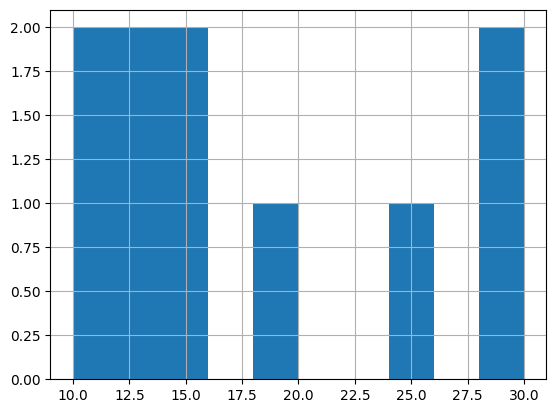

In [62]:
df['value'].hist()
plt.savefig('data/processed/histogram.png')


In [64]:
from src.utils import get_summary_stats

In [65]:
get_summary_stats

<function src.utils.get_summary_stats(df: pandas.core.frame.DataFrame) -> pandas.core.frame.DataFrame>

In [68]:
stats = get_summary_stats(df)
display(stats)

,value
count,10.000000
mean,17.600000
std,7.381659
min,10.000000
25%,12.250000
50%,14.500000
75%,23.250000
max,30.000000
